In [1]:
# import matplotlib
import matplotlib.pyplot as plt
# import pandas
import pandas as pd
import numpy as np

In [2]:
# train loss:
# read csv file
data_all = pd.read_csv("wandb_export_2025-01-07T01_44_02.365+01_00.csv")
# data = first 4 columns of data
data = data_all.iloc[
    :, [0, 1, 4, 7]
]  # selected columns are step, run1_loss, run2_loss, run3_loss
print(data.shape)
# data.head(10)
cut = data.iloc[3230:3240, :]
# data.tail(20)
# last index of first is 1009, step 1011
# last index of second is 3231, step 3233
# last index of third is 6430, step	6432

(6431, 4)


In [3]:
# np array to concat data into:
a = np.zeros((1010 + 3232 + 6431,))
a[:1010] = data.iloc[0:1010, 3]
a[1010:4242] = data.iloc[0:3232, 2]
a[4242:] = data.iloc[:, 1]
# plot a
# plt.plot(a* 32) # fix gradient accumulation bug

(33, 4)


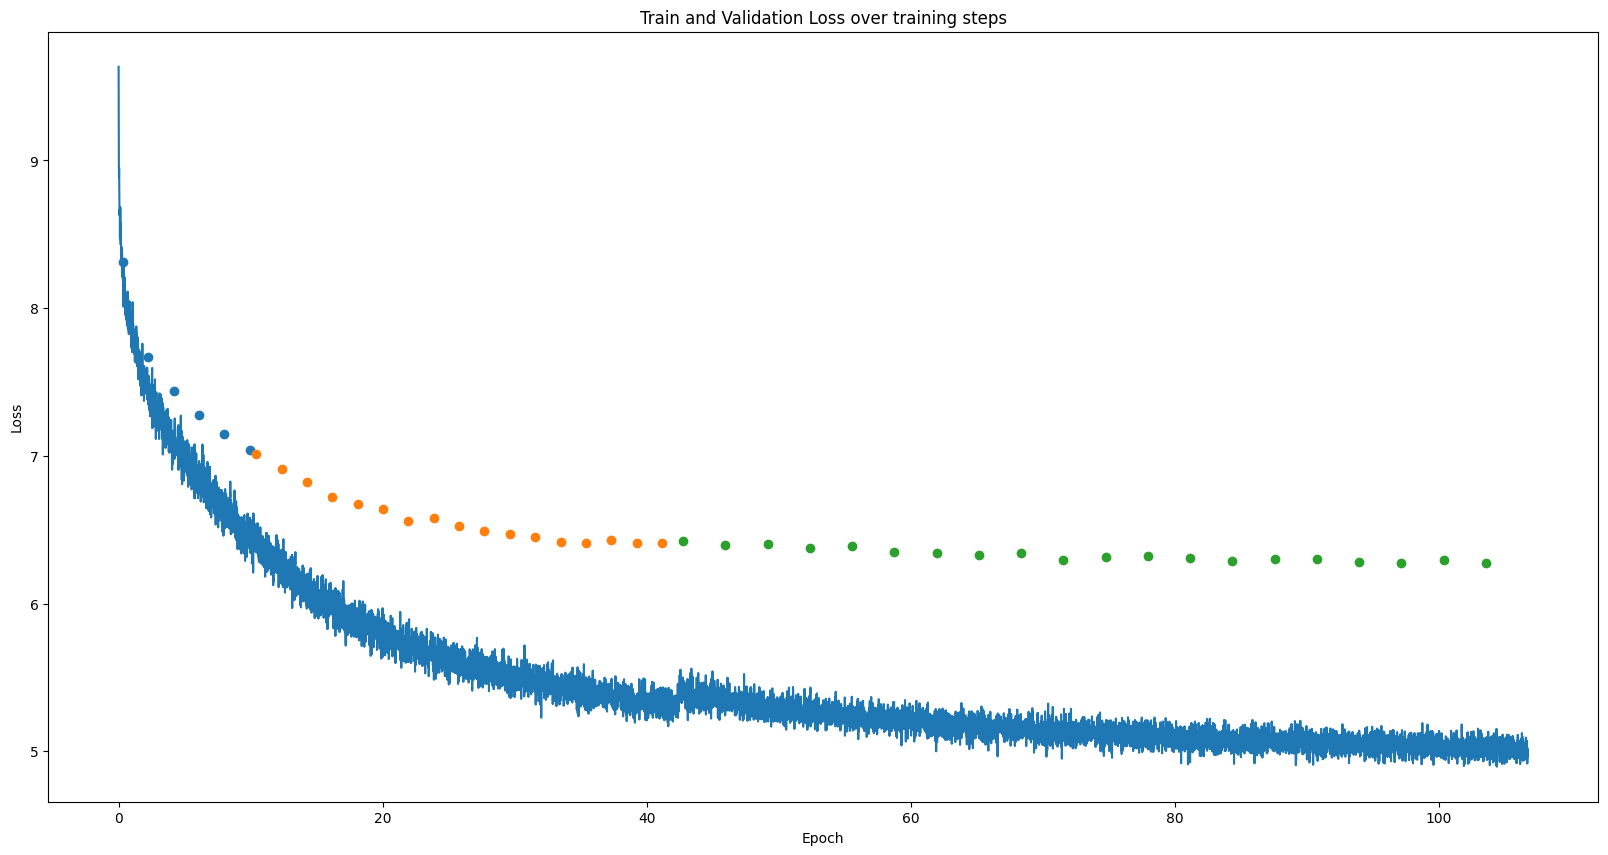

In [4]:
# VAL loss:
# read csv file
data = pd.read_csv("wandb_export_2025-01-07T01_43_53.618+01_00.csv")
# data = first 4 columns of data
data = data.iloc[
    :, [0, 1, 4, 7]
]  # selected columns are step, run1_loss, run2_loss, run3_loss
print(data.shape)
data.head(10)
cut = data.iloc[:, :]
cut.head(30)
# first = first and second column only
third = cut.iloc[:, [0, 1]]  # last
second = cut.iloc[:, [0, 2]]
first = cut.iloc[:, [0, 3]]  # first
first.head(10)
plt.figure(figsize=(20, 10))
plt.scatter(first.iloc[:, 0] / 100, first.iloc[:, 1])
second.iloc[:, 0] = second.iloc[:, 0] + 1010
plt.scatter(second.iloc[:, 0]/100, second.iloc[:, 1])
third.iloc[:, 0] = third.iloc[:, 0] + 4242
plt.scatter(third.iloc[:, 0]/100, third.iloc[:, 1])
plt.plot(np.arange(0,1010 + 3232 + 6431) / 100, a * 32)  # fix gradient accumulation bug
# make plot bigger:
plt.title("Train and Validation Loss over training steps") # 32 steps per epoch
# models/GoePT/model.py --eval-interval 6 --lr 0.05 --batch-size 24 --epochs 100 --eval-iter 50
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [5]:
# The scatterplot is the validation loss, the line plot is the training loss
# Both lines are concatenated into one, as the training crashed or was interrupted multiple times
# The small spike in train loss at step ca 4200 is likely due to the model state being last saved a bit before the crash.
# 
# The model was trained with the following parameters:
# --lr 0.05 --batch-size 24 --eval-iter 50
# and varying --eval-interval
